In [ ]:
# Paths in this notebook are relative to the repository root; move there when opened from analysis/.
import os
from pathlib import Path
if not Path('Experiments_constraints').is_dir() and (Path('..') / 'Experiments_constraints').is_dir():
    os.chdir('..')
print('CWD:', os.getcwd())

# PLOT only QUANTUM

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"

import torch
import numpy as np
import matplotlib.pyplot as plt
from os import path
import random

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ─── helper: load one experiment file ─────────────────────────────────────────
def load_data_wo_constraint(filename, device):
    data = torch.load(filename, map_location=device)
    actions          = data['actions'].to(torch.float32).to(device)
    true_response    = data['true_response'].to(torch.float32).to(device)
    response         = data['response'].to(torch.float32).to(device)
    num_of_queries   = data['queries'].to(device)
    eps              = data['uncertainty']
    error_init       = data['error_init']
    return actions, true_response, response, num_of_queries, eps, error_init


def plot_mean_and_CI_with_marker(time_steps, mean, lb, ub,
                                  color_mean=None, color_shading=None,
                                  marker=None, marker_size=12):
    fill = plt.fill_between(time_steps, ub, lb,
                            color=color_shading, alpha=.2)
    fill = None
    line = plt.plot(time_steps, mean, color_mean,
                    marker=marker, markersize=marker_size,
                    markevery=5000)
    line = line[0]
    return fill, line


# ─── True constraint oracle ────────────────────────────────────────────────────
from joblib import load as joblib_load
_tsai_wu_model = None

def get_tsai_wu():
    global _tsai_wu_model
    if _tsai_wu_model is None:
        _tsai_wu_model = joblib_load('surrogate_tsaiwu.joblib')
    return _tsai_wu_model

def is_feasible(action_np):
    """Return True if the action satisfies the Tsai-Wu constraint (FI < 1, i.e. c_val > 0)."""
    tsai_wu = get_tsai_wu()
    action_np = action_np.reshape(1, -1).astype(float)
    FI = tsai_wu.predict(action_np, return_std=False)
    c_val = 1.0 - float(FI)
    return c_val > 0.0


# ─── experiment parameters ────────────────────────────────────────────────────
lam    = 1.0
eta    = 1.0
Big_B  = 1.0
f_max  = 0

q_file_base = ('Experiments_constraint_continuous/'
               'Quantum_EXP_10_' + str(eta) + '_' + str(lam) +
               '_' + str(Big_B) + '_multi_gpu_noise_')
c_file_base = ('Experiments_constraint_continuous/'
               'Classic_SafeSet_' + str(eta) + '_' + str(lam) +
               '_' + str(1.0) + '_noise_')
c_acl_file_base = ('Experiments_constraint_continuous/'
               'Classic_Continuous_ACL_' + str(eta) + '_' + str(lam) +
               '_' + str(1.0) + '_noise_')
unc_file_base = ('Experiments_unconstraint_continuous/'
               'Classic_Unconstrained_8_' + str(eta) + '_' + str(lam) +
               '_' + str(Big_B) + '_noise_')
unc_q_file_base = ('Experiments_unconstraint_continuous/'
               'Quantum_Unconstrained_8_' + str(eta) + '_' + str(lam) +
               '_' + str(Big_B) + '_multi_gpu_noise_')


# ─── output containers (for cumulative regret + running minimum) ──────────────
all_regrets_1 = []   # quantum  noise=0.01
all_regrets_2 = []   # classic  noise=0.01
all_regrets_3 = []   # quantum  noise=0.04
all_regrets_4 = []   # classic  noise=0.04
all_regrets_5 = []   # classic ACL  noise=0.01
all_regrets_6 = []   # classic ACL  noise=0.04
all_regrets_7 = []   # classic unconstrained noise=0.01
all_regrets_8 = []   # classic unconstrained noise=0.04
all_regrets_9  = []  # quantum unconstrained noise=0.01
all_regrets_10 = []  # quantum unconstrained noise=0.04

all_runmin_1 = []
all_runmin_2 = []
all_runmin_3 = []
all_runmin_4 = []
all_runmin_5 = []
all_runmin_6 = []
all_runmin_7 = []
all_runmin_8 = []
all_runmin_9 = []
all_runmin_10 = []

runmin_len_1 = int(50000 + 100)
runmin_len_2 = int(50000 + 100)
runmin_len_3 = int(50000 + 100)
runmin_len_4 = int(50000 + 100)
runmin_len_5 = int(50000 + 100)
runmin_len_6 = int(50000 + 100)
runmin_len_7 = int(50000 + 100)
runmin_len_8 = int(50000 + 100)
runmin_len_9 = int(50000 + 100)
runmin_len_10 = int(50000 + 100)

min_len_1 = int(50000 + 100)
min_len_2 = int(50000 + 100)
min_len_3 = int(50000 + 100)
min_len_4 = int(50000 + 100)
min_len_5 = int(50000 + 100)
min_len_6 = int(50000 + 100)
min_len_7 = int(50000 + 100)
min_len_8 = int(50000 + 100)
min_len_9 = int(50000 + 100)
min_len_10 = int(50000 + 100)

min_01_q = []
min_01_c = []
min_02_q = []
min_02_c = []
min_01_acl = []
min_02_acl = []
min_01_unc = []
min_02_unc = []
min_01_unc_q = []
min_02_unc_q = []

safe_rate_01_q = []
safe_rate_01_c = []
safe_rate_02_q = []
safe_rate_02_c = []
safe_rate_01_acl = []
safe_rate_02_acl = []
safe_rate_01_unc = []
safe_rate_02_unc = []
safe_rate_01_unc_q = []
safe_rate_02_unc_q = []

violation_stats = {}

def record_safety(label, seed, safe_count, total_count):
    unsafe_count = total_count - safe_count
    stats = violation_stats.setdefault(label, {'safe': 0, 'unsafe': 0, 'total': 0, 'violation_rates': [], 'per_seed': []})
    stats['safe'] += int(safe_count)
    stats['unsafe'] += int(unsafe_count)
    stats['total'] += int(total_count)
    violation_rate = unsafe_count / total_count if total_count else np.nan
    stats['violation_rates'].append(violation_rate)
    stats['per_seed'].append({'seed': int(seed), 'safe': int(safe_count), 'unsafe': int(unsafe_count), 'total': int(total_count), 'violation_rate': violation_rate})

# ─── Single experiment set: exp_set_0 ────────────────────────────────────────
exp_tag = 'exp_set_0'
run_list = np.arange(5)

for itr in run_list:

    # ── Quantum, noise=0.01 ──────────────────────────────────────────────────
    noise_tag = str(0.1**2)
    q_file    = q_file_base + noise_tag + '/' + exp_tag + '/'
    q_actions, q_true_response, q_response, num_of_queries, eps, error_init = \
        load_data_wo_constraint(q_file + noise_tag + 'quan_training_data_' + str(itr) + '_.pth',
                                device=device)

    values = q_true_response.detach().cpu().numpy()
    min_01_q.append(min(values).item())

    actions_np = q_actions.detach().cpu().numpy()
    n_safe_q01 = sum(1 for a in actions_np if is_feasible(a))
    safe_rate_01_q.append(n_safe_q01 / len(actions_np))
    record_safety('Q-Safe BO noise=0.01', itr, n_safe_q01, len(actions_np))
    print(f'Quantum 0.1 safe_queried_rate: {n_safe_q01}/{len(actions_np)} = {n_safe_q01/len(actions_np):.4f}')

    track_queries = num_of_queries.detach().cpu().numpy().astype(np.int32)
    values_new = []
    for ii in range(len(values)):
        values_new += list(np.repeat(values[ii], track_queries[ii]))
    values      = np.array(values_new)
    values      = np.squeeze(np.abs(f_max - values))
    values_acc  = np.cumsum(values)
    min_len_1   = np.min([min_len_1, len(values_acc)])
    all_regrets_1.append(values_acc)
    values_runmin = np.minimum.accumulate(values)
    runmin_len_1  = np.min([runmin_len_1, len(values_runmin)])
    all_runmin_1.append(values_runmin)

    # ── Classic, noise=0.01 ──────────────────────────────────────────────────
    noise_tag_classic = str(0.1**2)
    c_file = c_file_base + noise_tag + '/' + exp_tag + '/'
    c_actions, c_true_response, c_response, c_num_of_queries, c_eps, error_init = \
        load_data_wo_constraint(c_file + noise_tag_classic + 'classic_safeset_training_data_' + str(itr) + '_.pth',
                                device=device)
    c_values = c_true_response.detach().cpu().numpy()
    min_01_c.append(min(c_values).item())

    c_actions_np = c_actions.detach().cpu().numpy()
    n_safe_c01   = sum(1 for a in c_actions_np if is_feasible(a))
    safe_rate_01_c.append(n_safe_c01 / len(c_actions_np))
    record_safety('C-Safe BO noise=0.01', itr, n_safe_c01, len(c_actions_np))
    print(f'Classic 0.1 safe_queried_rate: {n_safe_c01}/{len(c_actions_np)} = {n_safe_c01/len(c_actions_np):.4f}')

    c_track_queries = c_num_of_queries.detach().cpu().numpy().astype(np.int32)
    c_values_new = []
    for ii in range(len(c_values)):
        c_values_new += list(np.repeat(c_values[ii], c_track_queries[ii]))
    c_values     = np.array(c_values_new)
    c_values     = np.squeeze(np.abs(f_max - c_values))
    c_values_acc = np.cumsum(c_values)
    min_len_2    = np.min([min_len_2, len(c_values_acc)])
    all_regrets_2.append(c_values_acc)
    c_values_runmin = np.minimum.accumulate(c_values)
    runmin_len_2   = np.min([runmin_len_2, len(c_values_runmin)])
    all_runmin_2.append(c_values_runmin)

    # ── Quantum, noise=0.04 ──────────────────────────────────────────────────
    noise_tag = str(0.2**2)
    q_file    = q_file_base + noise_tag + '/' + exp_tag + '/'
    q_actions, q_true_response, q_response, num_of_queries, eps, error_init = \
        load_data_wo_constraint(q_file + noise_tag + 'quan_training_data_' + str(itr) + '_.pth',
                                device=device)
    values = q_true_response.detach().cpu().numpy()
    min_02_q.append(min(values).item())

    actions_np = q_actions.detach().cpu().numpy()
    n_safe_q04 = sum(1 for a in actions_np if is_feasible(a))
    safe_rate_02_q.append(n_safe_q04 / len(actions_np))
    record_safety('Q-Safe BO noise=0.04', itr, n_safe_q04, len(actions_np))
    print(f'Quantum 0.2 safe_queried_rate: {n_safe_q04}/{len(actions_np)} = {n_safe_q04/len(actions_np):.4f}')

    track_queries = num_of_queries.detach().cpu().numpy().astype(np.int32)
    values_new = []
    for ii in range(len(values)):
        values_new += list(np.repeat(values[ii], track_queries[ii]))
    values      = np.array(values_new)
    values      = np.squeeze(np.abs(f_max - values))
    values_acc  = np.cumsum(values)
    min_len_3   = np.min([min_len_3, len(values_acc)])
    all_regrets_3.append(values_acc)
    values_runmin = np.minimum.accumulate(values)
    runmin_len_3  = np.min([runmin_len_3, len(values_runmin)])
    all_runmin_3.append(values_runmin)

    # ── Classic, noise=0.04 ──────────────────────────────────────────────────
    noise_tag_2 = str(0.2**2)
    c_file = c_file_base + noise_tag + '/' + exp_tag + '/'
    c_actions, c_true_response, c_response, c_num_of_queries, c_eps, error_init = \
        load_data_wo_constraint(c_file + noise_tag_2 + 'classic_safeset_training_data_' + str(itr) + '_.pth',
                                device=device)
    c_values = c_true_response.detach().cpu().numpy()
    min_02_c.append(min(c_values).item())

    c_actions_np = c_actions.detach().cpu().numpy()
    n_safe_c04   = sum(1 for a in c_actions_np if is_feasible(a))
    safe_rate_02_c.append(n_safe_c04 / len(c_actions_np))
    record_safety('C-Safe BO noise=0.04', itr, n_safe_c04, len(c_actions_np))
    print(f'Classic 0.2 safe_queried_rate: {n_safe_c04}/{len(c_actions_np)} = {n_safe_c04/len(c_actions_np):.4f}')

    c_track_queries = c_num_of_queries.detach().cpu().numpy().astype(np.int32)
    c_values_new = []
    for ii in range(len(c_values)):
        c_values_new += list(np.repeat(c_values[ii], c_track_queries[ii]))
    c_values     = np.array(c_values_new)
    c_values     = np.squeeze(np.abs(f_max - c_values))
    c_values_acc = np.cumsum(c_values)
    min_len_4    = np.min([min_len_4, len(c_values_acc)])
    all_regrets_4.append(c_values_acc)
    c_values_runmin = np.minimum.accumulate(c_values)
    runmin_len_4   = np.min([runmin_len_4, len(c_values_runmin)])
    all_runmin_4.append(c_values_runmin)

    # ── Classic ACL, noise=0.01 ─────────────────────────────────────────────
    noise_tag_acl = str(0.1**2)
    c_acl_file = c_acl_file_base + noise_tag_acl + '/' + exp_tag + '/'
    c_acl_actions, c_acl_true_response, c_acl_response, c_acl_num_of_queries, c_acl_eps, error_init = \
        load_data_wo_constraint(c_acl_file + noise_tag_acl + 'training_data_' + str(itr) + '_.pth',
                                device=device)

    c_acl_values = c_acl_true_response.detach().cpu().numpy()
    min_01_acl.append(min(c_acl_values).item())
    c_acl_actions_np = c_acl_actions.detach().cpu().numpy()
    n_safe_acl01   = sum(1 for a in c_acl_actions_np if is_feasible(a))
    safe_rate_01_acl.append(n_safe_acl01 / len(c_acl_actions_np))
    record_safety('BO-ACL noise=0.01', itr, n_safe_acl01, len(c_acl_actions_np))
    print(f'Classic ACL 0.1 safe_queried_rate: {n_safe_acl01}/{len(c_acl_actions_np)} = {n_safe_acl01/len(c_acl_actions_np):.4f}')
    c_acl_track_queries = c_acl_num_of_queries.detach().cpu().numpy().astype(np.int32)
    c_acl_values_new = []
    for ii in range(len(c_acl_values)):
        c_acl_values_new += list(np.repeat(c_acl_values[ii], c_acl_track_queries[ii]))
    c_acl_values     = np.array(c_acl_values_new)
    c_acl_values     = np.squeeze(np.abs(f_max - c_acl_values))
    c_acl_values_acc = np.cumsum(c_acl_values)
    min_len_5    = np.min([min_len_5, len(c_acl_values_acc)])
    all_regrets_5.append(c_acl_values_acc)
    c_acl_values_runmin = np.minimum.accumulate(c_acl_values)
    runmin_len_5   = np.min([runmin_len_5, len(c_acl_values_runmin)])
    all_runmin_5.append(c_acl_values_runmin)
    
    # ── Classic ACL, noise=0.04 ─────────────────────────────────────────────
    noise_tag_acl = str(0.2**2)
    c_acl_file = c_acl_file_base + noise_tag_acl + '/' + exp_tag + '/'
    c_acl_actions, c_acl_true_response, c_acl_response, c_acl_num_of_queries, c_acl_eps, error_init = \
        load_data_wo_constraint(c_acl_file + noise_tag_acl + 'training_data_' + str(itr) + '_.pth',
                                device=device)

    c_acl_values = c_acl_true_response.detach().cpu().numpy()
    min_02_acl.append(min(c_acl_values).item())
    c_acl_actions_np = c_acl_actions.detach().cpu().numpy()
    n_safe_acl02   = sum(1 for a in c_acl_actions_np if is_feasible(a))
    safe_rate_02_acl.append(n_safe_acl02 / len(c_acl_actions_np))
    record_safety('BO-ACL noise=0.04', itr, n_safe_acl02, len(c_acl_actions_np))
    print(f'Classic ACL 0.2 safe_queried_rate: {n_safe_acl02}/{len(c_acl_actions_np)} = {n_safe_acl02/len(c_acl_actions_np):.4f}')
    c_acl_track_queries = c_acl_num_of_queries.detach().cpu().numpy().astype(np.int32)
    c_acl_values_new = []
    for ii in range(len(c_acl_values)):
        c_acl_values_new += list(np.repeat(c_acl_values[ii], c_acl_track_queries[ii]))
    c_acl_values     = np.array(c_acl_values_new)
    c_acl_values     = np.squeeze(np.abs(f_max - c_acl_values))
    c_acl_values_acc = np.cumsum(c_acl_values)
    min_len_6    = np.min([min_len_6, len(c_acl_values_acc)])
    all_regrets_6.append(c_acl_values_acc)
    c_acl_values_runmin = np.minimum.accumulate(c_acl_values)
    all_runmin_6.append(c_acl_values_runmin)

    # ── Classic Unconstrained, noise=0.01 ───────────────────────────────────
    noise_tag_unc = str(0.1**2)
    unc_file = unc_file_base + noise_tag_unc + '/' + exp_tag + '/'
    unc_actions, unc_true_response, unc_response, unc_num_of_queries, unc_eps, error_init = \
        load_data_wo_constraint(unc_file + noise_tag_unc + 'classic_unconstrained_training_data_' + str(itr) + '_.pth',
                                device=device)
    unc_values = unc_true_response.detach().cpu().numpy()
    min_01_unc.append(min(unc_values).item())
    unc_actions_np = unc_actions.detach().cpu().numpy()
    n_safe_unc01   = sum(1 for a in unc_actions_np if is_feasible(a))
    safe_rate_01_unc.append(n_safe_unc01 / len(unc_actions_np))
    record_safety('BO-Unconstrained noise=0.01', itr, n_safe_unc01, len(unc_actions_np))
    print(f'Classic Unconstrained 0.1 safe_queried_rate: {n_safe_unc01}/{len(unc_actions_np)} = {n_safe_unc01/len(unc_actions_np):.4f}')
    unc_track_queries = unc_num_of_queries.detach().cpu().numpy().astype(np.int32)
    unc_values_new = []
    for ii in range(len(unc_values)):
        unc_values_new += list(np.repeat(unc_values[ii], unc_track_queries[ii]))
    unc_values     = np.array(unc_values_new)
    unc_values     = np.squeeze(np.abs(f_max - unc_values))
    unc_values_acc = np.cumsum(unc_values)
    min_len_7    = np.min([min_len_7, len(unc_values_acc)])
    all_regrets_7.append(unc_values_acc)
    unc_values_runmin = np.minimum.accumulate(unc_values)
    runmin_len_7   = np.min([runmin_len_7, len(unc_values_runmin)])
    all_runmin_7.append(unc_values_runmin)

    # ── Classic Unconstrained, noise=0.04 ───────────────────────────────────
    noise_tag_unc = str(0.2**2)
    unc_file = unc_file_base + noise_tag_unc + '/' + exp_tag + '/'
    unc_actions, unc_true_response, unc_response, unc_num_of_queries, unc_eps, error_init = \
        load_data_wo_constraint(unc_file + noise_tag_unc + 'classic_unconstrained_training_data_' + str(itr) + '_.pth',
                                device=device)
    unc_values = unc_true_response.detach().cpu().numpy()
    min_02_unc.append(min(unc_values).item())
    unc_actions_np = unc_actions.detach().cpu().numpy()
    n_safe_unc02   = sum(1 for a in unc_actions_np if is_feasible(a))
    safe_rate_02_unc.append(n_safe_unc02 / len(unc_actions_np))
    record_safety('BO-Unconstrained noise=0.04', itr, n_safe_unc02, len(unc_actions_np))
    print(f'Classic Unconstrained 0.2 safe_queried_rate: {n_safe_unc02}/{len(unc_actions_np)} = {n_safe_unc02/len(unc_actions_np):.4f}')
    unc_track_queries = unc_num_of_queries.detach().cpu().numpy().astype(np.int32)
    unc_values_new = []
    for ii in range(len(unc_values)):
        unc_values_new += list(np.repeat(unc_values[ii], unc_track_queries[ii]))
    unc_values     = np.array(unc_values_new)
    unc_values     = np.squeeze(np.abs(f_max - unc_values))
    unc_values_acc = np.cumsum(unc_values)
    min_len_8    = np.min([min_len_8, len(unc_values_acc)])
    all_regrets_8.append(unc_values_acc)
    unc_values_runmin = np.minimum.accumulate(unc_values)
    runmin_len_8   = np.min([runmin_len_8, len(unc_values_runmin)])
    all_runmin_8.append(unc_values_runmin)

    # ── Quantum Unconstrained, noise=0.01 ────────────────────
    unc_q_noise_tag = '0.01'
    unc_q_file = unc_q_file_base + unc_q_noise_tag + '/' + exp_tag + '/'
    uq_actions, uq_true_response, uq_response, uq_num_of_queries, uq_eps, error_init = \
        load_data_wo_constraint(unc_q_file + unc_q_noise_tag + 'quan_unconstrained_training_data_' + str(itr) + '_.pth',
                                device=device)
    uq_values = uq_true_response.detach().cpu().numpy()
    min_01_unc_q.append(min(uq_values).item())
    uq_actions_np = uq_actions.detach().cpu().numpy()
    n_safe_unc_q01 = sum(1 for a in uq_actions_np if is_feasible(a))
    safe_rate_01_unc_q.append(n_safe_unc_q01 / len(uq_actions_np))
    record_safety('Q-Unconstrained noise=0.01', itr, n_safe_unc_q01, len(uq_actions_np))
    print(f'Quantum Unconstrained 0.1 safe_queried_rate: {n_safe_unc_q01}/{len(uq_actions_np)} = {n_safe_unc_q01/len(uq_actions_np):.4f}')
    uq_track_queries = uq_num_of_queries.detach().cpu().numpy().astype(np.int32)
    uq_values_new = []
    for ii in range(len(uq_values)):
        uq_values_new += list(np.repeat(uq_values[ii], uq_track_queries[ii]))
    uq_values     = np.array(uq_values_new)
    uq_values     = np.squeeze(np.abs(f_max - uq_values))
    uq_values_acc = np.cumsum(uq_values)
    min_len_9    = np.min([min_len_9, len(uq_values_acc)])
    all_regrets_9.append(uq_values_acc)
    uq_values_runmin = np.minimum.accumulate(uq_values)
    runmin_len_9   = np.min([runmin_len_9, len(uq_values_runmin)])
    all_runmin_9.append(uq_values_runmin)

    # ── Quantum Unconstrained, noise=0.04 ────────────────────
    unc_q_noise_tag = '0.04'
    unc_q_file = unc_q_file_base + unc_q_noise_tag + '/' + exp_tag + '/'
    uq_actions, uq_true_response, uq_response, uq_num_of_queries, uq_eps, error_init = \
        load_data_wo_constraint(unc_q_file + unc_q_noise_tag + 'quan_unconstrained_training_data_' + str(itr) + '_.pth',
                                device=device)
    uq_values = uq_true_response.detach().cpu().numpy()
    min_02_unc_q.append(min(uq_values).item())
    uq_actions_np = uq_actions.detach().cpu().numpy()
    n_safe_unc_q02 = sum(1 for a in uq_actions_np if is_feasible(a))
    safe_rate_02_unc_q.append(n_safe_unc_q02 / len(uq_actions_np))
    record_safety('Q-Unconstrained noise=0.04', itr, n_safe_unc_q02, len(uq_actions_np))
    print(f'Quantum Unconstrained 0.2 safe_queried_rate: {n_safe_unc_q02}/{len(uq_actions_np)} = {n_safe_unc_q02/len(uq_actions_np):.4f}')
    uq_track_queries = uq_num_of_queries.detach().cpu().numpy().astype(np.int32)
    uq_values_new = []
    for ii in range(len(uq_values)):
        uq_values_new += list(np.repeat(uq_values[ii], uq_track_queries[ii]))
    uq_values     = np.array(uq_values_new)
    uq_values     = np.squeeze(np.abs(f_max - uq_values))
    uq_values_acc = np.cumsum(uq_values)
    min_len_10    = np.min([min_len_10, len(uq_values_acc)])
    all_regrets_10.append(uq_values_acc)
    uq_values_runmin = np.minimum.accumulate(uq_values)
    runmin_len_10   = np.min([runmin_len_10, len(uq_values_runmin)])
    all_runmin_10.append(uq_values_runmin)


# ─── summary statistics for safe_queried_rate ─────────────────────────────────
print()
print('=== safe_queried_rate summary (exp_set_0) ===')
print(f'Quantum noise=0.01: mean={np.mean(safe_rate_01_q):.4f} \u00b1 {np.std(safe_rate_01_q):.4f}')
print(f'Classic noise=0.01: mean={np.mean(safe_rate_01_c):.4f} \u00b1 {np.std(safe_rate_01_c):.4f}')
print(f'Quantum noise=0.04: mean={np.mean(safe_rate_02_q):.4f} \u00b1 {np.std(safe_rate_02_q):.4f}')
print(f'Classic noise=0.04: mean={np.mean(safe_rate_02_c):.4f} \u00b1 {np.std(safe_rate_02_c):.4f}')
print(f'Classic ACL noise=0.01: mean={np.mean(safe_rate_01_acl):.4f} \u00b1 {np.std(safe_rate_01_acl):.4f}')
print(f'Classic ACL noise=0.04: mean={np.mean(safe_rate_02_acl):.4f} \u00b1 {np.std(safe_rate_02_acl):.4f}')
print(f'Classic Unconstrained noise=0.01: mean={np.mean(safe_rate_01_unc):.4f} \u00b1 {np.std(safe_rate_01_unc):.4f}')
print(f'Classic Unconstrained noise=0.04: mean={np.mean(safe_rate_02_unc):.4f} \u00b1 {np.std(safe_rate_02_unc):.4f}')
print(f'Quantum Unconstrained noise=0.01: mean={np.mean(safe_rate_01_unc_q):.4f} \u00b1 {np.std(safe_rate_01_unc_q):.4f}')
print(f'Quantum Unconstrained noise=0.04: mean={np.mean(safe_rate_02_unc_q):.4f} \u00b1 {np.std(safe_rate_02_unc_q):.4f}')

print()
print(f'=== violation_rate summary ({exp_tag}, aligned with cumulative/running-minimum plots) ===')
print('Violation rate = unsafe / total queried points; safe condition: (1 - FI) > 0')
for label, stats in violation_stats.items():
    safe = stats['safe']
    unsafe = stats['unsafe']
    total = stats['total']
    violation_rate = unsafe / total if total else np.nan
    safe_rate = safe / total if total else np.nan
    mean_seed_violation = np.nanmean(stats['violation_rates'])
    std_seed_violation = np.nanstd(stats['violation_rates'])
    print(
        f'{label}: safe={safe}, unsafe={unsafe}, total={total}, '
        f'safe_rate={safe_rate:.4f}, violation_rate={violation_rate:.4f}, '
        f'per_seed_violation={mean_seed_violation:.4f} \u00b1 {std_seed_violation:.4f}'
    )

print()
print(f'=== violation_rate per seed ({exp_tag}) ===')
for label, stats in violation_stats.items():
    print(label)
    for row in stats['per_seed']:
        print(
            f"  seed={row['seed']}: safe={row['safe']}, unsafe={row['unsafe']}, "
            f"total={row['total']}, violation_rate={row['violation_rate']:.6f}"
        )
    print(f"  std_violation_rate={np.nanstd(stats['violation_rates']):.6f}")
    print()

Quantum 0.1 safe_queried_rate: 343/343 = 1.0000
Classic 0.1 safe_queried_rate: 248/248 = 1.0000
Quantum 0.2 safe_queried_rate: 158/158 = 1.0000
Classic 0.2 safe_queried_rate: 99/99 = 1.0000
Classic ACL 0.1 safe_queried_rate: 265/597 = 0.4439
Classic ACL 0.2 safe_queried_rate: 109/301 = 0.3621
Quantum 0.1 safe_queried_rate: 371/371 = 1.0000
Classic 0.1 safe_queried_rate: 209/209 = 1.0000
Quantum 0.2 safe_queried_rate: 149/149 = 1.0000
Classic 0.2 safe_queried_rate: 99/99 = 1.0000
Classic ACL 0.1 safe_queried_rate: 262/597 = 0.4389
Classic ACL 0.2 safe_queried_rate: 111/301 = 0.3688
Quantum 0.1 safe_queried_rate: 367/367 = 1.0000
Classic 0.1 safe_queried_rate: 224/224 = 1.0000
Quantum 0.2 safe_queried_rate: 157/157 = 1.0000
Classic 0.2 safe_queried_rate: 94/94 = 1.0000
Classic ACL 0.1 safe_queried_rate: 255/597 = 0.4271
Classic ACL 0.2 safe_queried_rate: 101/301 = 0.3355
Quantum 0.1 safe_queried_rate: 327/327 = 1.0000
Classic 0.1 safe_queried_rate: 258/258 = 1.0000
Quantum 0.2 safe_queri

In [3]:
print('quantum 0.1 min mean {0} +- {1}:'.format(np.mean(min_01_q), np.std(min_01_q)))
print('classic 0.1 min mean {0} +- {1}'.format(np.mean(min_01_c), np.std(min_01_c)))
print('classic ACL 0.1 min mean {0} +- {1}'.format(np.mean(min_01_acl), np.std(min_01_acl)))

print('quantum 0.2 min mean {0} +- {1}'.format(np.mean(min_02_q), np.std(min_02_q)))
print('classic 0.2 min mean {0} +- {1}'.format(np.mean(min_02_c), np.std(min_02_c)))
print('classic ACL 0.2 min mean {0} +- {1}'.format(np.mean(min_02_acl), np.std(min_02_acl)))

print()
print('=== safe_queried_rate ===')
print(f'Quantum noise=0.01: mean={np.mean(safe_rate_01_q):.4f} +- {np.std(safe_rate_01_q):.4f}')
print(f'Classic noise=0.01: mean={np.mean(safe_rate_01_c):.4f} +- {np.std(safe_rate_01_c):.4f}')
print(f'Quantum noise=0.04: mean={np.mean(safe_rate_02_q):.4f} +- {np.std(safe_rate_02_q):.4f}')
print(f'Classic noise=0.04: mean={np.mean(safe_rate_02_c):.4f} +- {np.std(safe_rate_02_c):.4f}')
print(f'Classic ACL noise=0.01: mean={np.mean(safe_rate_01_acl):.4f} +- {np.std(safe_rate_01_acl):.4f}')


quantum 0.1 min mean 0.030904893949627876 +- 0.00632393608621079:
classic 0.1 min mean 0.03363009728491306 +- 0.003835515119505774
classic ACL 0.1 min mean 0.0333135936409235 +- 0.010996220301991924
quantum 0.2 min mean 0.04481165781617165 +- 0.013977062305953511
classic 0.2 min mean 0.040734848380088805 +- 0.005753291663185337
classic ACL 0.2 min mean 0.03291624188423157 +- 0.011428472583254705

=== safe_queried_rate ===
Quantum noise=0.01: mean=1.0000 +- 0.0000
Classic noise=0.01: mean=1.0000 +- 0.0000
Quantum noise=0.04: mean=1.0000 +- 0.0000
Classic noise=0.04: mean=1.0000 +- 0.0000
Classic ACL noise=0.01: mean=0.4405 +- 0.0074


In [4]:
lw = 2.0
plt.rc('font', size=12)

# high-res on screen + save
plt.rcParams['figure.dpi'] = 150      # notebook/interactive
plt.rcParams['savefig.dpi'] = 600     # file output

all_regrets_1 = [a[:min_len_1] for a in all_regrets_1]
all_regrets_1_np = np.array(all_regrets_1)
all_regrets_1_np_mean = np.mean(all_regrets_1_np, axis=0)
all_regrets_1_np_stderr = np.std(all_regrets_1_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_1_np_ub = all_regrets_1_np_mean + all_regrets_1_np_stderr
all_regrets_1_np_lb = all_regrets_1_np_mean - all_regrets_1_np_stderr

all_regrets_2 = [a[:min_len_2] for a in all_regrets_2]
all_regrets_2_np = np.array(all_regrets_2)
all_regrets_2_np_mean = np.mean(all_regrets_2_np, axis=0)
all_regrets_2_np_stderr = np.std(all_regrets_2_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_2_np_ub = all_regrets_2_np_mean + all_regrets_2_np_stderr
all_regrets_2_np_lb = all_regrets_2_np_mean - all_regrets_2_np_stderr

all_regrets_3 = [a[:min_len_3] for a in all_regrets_3]
all_regrets_3_np = np.array(all_regrets_3)
all_regrets_3_np_mean = np.mean(all_regrets_3_np, axis=0)
all_regrets_3_np_stderr = np.std(all_regrets_3_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_3_np_ub = all_regrets_3_np_mean + all_regrets_3_np_stderr
all_regrets_3_np_lb = all_regrets_3_np_mean - all_regrets_3_np_stderr

all_regrets_4 = [a[:min_len_4] for a in all_regrets_4]
all_regrets_4_np = np.array(all_regrets_4)
all_regrets_4_np_mean = np.mean(all_regrets_4_np, axis=0)
all_regrets_4_np_stderr = np.std(all_regrets_4_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_4_np_ub = all_regrets_4_np_mean + all_regrets_4_np_stderr
all_regrets_4_np_lb = all_regrets_4_np_mean - all_regrets_4_np_stderr

all_regrets_5 = [a[:min_len_5] for a in all_regrets_5]
all_regrets_5_np = np.array(all_regrets_5)
all_regrets_5_np_mean = np.mean(all_regrets_5_np, axis=0)
all_regrets_5_np_stderr = np.std(all_regrets_5_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_5_np_ub = all_regrets_5_np_mean + all_regrets_5_np_stderr
all_regrets_5_np_lb = all_regrets_5_np_mean - all_regrets_5_np_stderr

all_regrets_6 = [a[:min_len_6] for a in all_regrets_6]
all_regrets_6_np = np.array(all_regrets_6)
all_regrets_6_np_mean = np.mean(all_regrets_6_np, axis=0)
all_regrets_6_np_stderr = np.std(all_regrets_6_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_6_np_ub = all_regrets_6_np_mean + all_regrets_6_np_stderr
all_regrets_6_np_lb = all_regrets_6_np_mean - all_regrets_6_np_stderr

all_regrets_7 = [a[:min_len_7] for a in all_regrets_7]
all_regrets_7_np = np.array(all_regrets_7)
all_regrets_7_np_mean = np.mean(all_regrets_7_np, axis=0)
all_regrets_7_np_stderr = np.std(all_regrets_7_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_7_np_ub = all_regrets_7_np_mean + all_regrets_7_np_stderr
all_regrets_7_np_lb = all_regrets_7_np_mean - all_regrets_7_np_stderr

all_regrets_8 = [a[:min_len_8] for a in all_regrets_8]
all_regrets_8_np = np.array(all_regrets_8)
all_regrets_8_np_mean = np.mean(all_regrets_8_np, axis=0)
all_regrets_8_np_stderr = np.std(all_regrets_8_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_8_np_ub = all_regrets_8_np_mean + all_regrets_8_np_stderr
all_regrets_8_np_lb = all_regrets_8_np_mean - all_regrets_8_np_stderr

all_regrets_9 = [a[:min_len_9] for a in all_regrets_9]
all_regrets_9_np = np.array(all_regrets_9)
all_regrets_9_np_mean = np.mean(all_regrets_9_np, axis=0)
all_regrets_9_np_stderr = np.std(all_regrets_9_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_9_np_ub = all_regrets_9_np_mean + all_regrets_9_np_stderr
all_regrets_9_np_lb = all_regrets_9_np_mean - all_regrets_9_np_stderr

all_regrets_10 = [a[:min_len_10] for a in all_regrets_10]
all_regrets_10_np = np.array(all_regrets_10)
all_regrets_10_np_mean = np.mean(all_regrets_10_np, axis=0)
all_regrets_10_np_stderr = np.std(all_regrets_10_np, axis=0) / (np.sqrt(len(run_list)))
all_regrets_10_np_ub = all_regrets_10_np_mean + all_regrets_10_np_stderr
all_regrets_10_np_lb = all_regrets_10_np_mean - all_regrets_10_np_stderr

color_list = ["#625be6", "#edc709", '#2ca02c', '#d62728', '#9467bd', '#17becf', '#ff7f0e', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] 
marker_list = ["v", "D", "s", "o", "^", "P"]
inds = np.arange(1, 1e6+1)
marker_size = 8


### Running Minimum

In [5]:
lw = 2.0
plt.rc('font', size=12)

# high-res on screen + save
plt.rcParams['figure.dpi'] = 600      # notebook/interactive
plt.rcParams['savefig.dpi'] = 600     # file output

# ─── compute mean ± stderr for each running-minimum series ───
all_runmin_1_t = [a[:runmin_len_1] for a in all_runmin_1]
all_runmin_1_np = np.array(all_runmin_1_t)
all_runmin_1_np_mean = np.mean(all_runmin_1_np, axis=0)
all_runmin_1_np_stderr = np.std(all_runmin_1_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_1_np_ub = all_runmin_1_np_mean + all_runmin_1_np_stderr
all_runmin_1_np_lb = all_runmin_1_np_mean - all_runmin_1_np_stderr

all_runmin_2_t = [a[:runmin_len_2] for a in all_runmin_2]
all_runmin_2_np = np.array(all_runmin_2_t)
all_runmin_2_np_mean = np.mean(all_runmin_2_np, axis=0)
all_runmin_2_np_stderr = np.std(all_runmin_2_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_2_np_ub = all_runmin_2_np_mean + all_runmin_2_np_stderr
all_runmin_2_np_lb = all_runmin_2_np_mean - all_runmin_2_np_stderr

all_runmin_3_t = [a[:runmin_len_3] for a in all_runmin_3]
all_runmin_3_np = np.array(all_runmin_3_t)
all_runmin_3_np_mean = np.mean(all_runmin_3_np, axis=0)
all_runmin_3_np_stderr = np.std(all_runmin_3_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_3_np_ub = all_runmin_3_np_mean + all_runmin_3_np_stderr
all_runmin_3_np_lb = all_runmin_3_np_mean - all_runmin_3_np_stderr

all_runmin_4_t = [a[:runmin_len_4] for a in all_runmin_4]
all_runmin_4_np = np.array(all_runmin_4_t)
all_runmin_4_np_mean = np.mean(all_runmin_4_np, axis=0)
all_runmin_4_np_stderr = np.std(all_runmin_4_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_4_np_ub = all_runmin_4_np_mean + all_runmin_4_np_stderr
all_runmin_4_np_lb = all_runmin_4_np_mean - all_runmin_4_np_stderr

all_runmin_5_t = [a[:runmin_len_5] for a in all_runmin_5]
all_runmin_5_np = np.array(all_runmin_5_t)
all_runmin_5_np_mean = np.mean(all_runmin_5_np, axis=0)
all_runmin_5_np_stderr = np.std(all_runmin_5_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_5_np_ub = all_runmin_5_np_mean + all_runmin_5_np_stderr
all_runmin_5_np_lb = all_runmin_5_np_mean - all_runmin_5_np_stderr

all_runmin_6_t = [a[:runmin_len_6] for a in all_runmin_6]
all_runmin_6_np = np.array(all_runmin_6_t)
all_runmin_6_np_mean = np.mean(all_runmin_6_np, axis=0)
all_runmin_6_np_stderr = np.std(all_runmin_6_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_6_np_ub = all_runmin_6_np_mean + all_runmin_6_np_stderr
all_runmin_6_np_lb = all_runmin_6_np_mean - all_runmin_6_np_stderr

all_runmin_7_t = [a[:runmin_len_7] for a in all_runmin_7]
all_runmin_7_np = np.array(all_runmin_7_t)
all_runmin_7_np_mean = np.mean(all_runmin_7_np, axis=0)
all_runmin_7_np_stderr = np.std(all_runmin_7_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_7_np_ub = all_runmin_7_np_mean + all_runmin_7_np_stderr
all_runmin_7_np_lb = all_runmin_7_np_mean - all_runmin_7_np_stderr

all_runmin_8_t = [a[:runmin_len_8] for a in all_runmin_8]
all_runmin_8_np = np.array(all_runmin_8_t)
all_runmin_8_np_mean = np.mean(all_runmin_8_np, axis=0)
all_runmin_8_np_stderr = np.std(all_runmin_8_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_8_np_ub = all_runmin_8_np_mean + all_runmin_8_np_stderr
all_runmin_8_np_lb = all_runmin_8_np_mean - all_runmin_8_np_stderr

all_runmin_9_t = [a[:runmin_len_9] for a in all_runmin_9]
all_runmin_9_np = np.array(all_runmin_9_t)
all_runmin_9_np_mean = np.mean(all_runmin_9_np, axis=0)
all_runmin_9_np_stderr = np.std(all_runmin_9_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_9_np_ub = all_runmin_9_np_mean + all_runmin_9_np_stderr
all_runmin_9_np_lb = all_runmin_9_np_mean - all_runmin_9_np_stderr

all_runmin_10_t = [a[:runmin_len_10] for a in all_runmin_10]
all_runmin_10_np = np.array(all_runmin_10_t)
all_runmin_10_np_mean = np.mean(all_runmin_10_np, axis=0)
all_runmin_10_np_stderr = np.std(all_runmin_10_np, axis=0) / (np.sqrt(len(run_list)))
all_runmin_10_np_ub = all_runmin_10_np_mean + all_runmin_10_np_stderr
all_runmin_10_np_lb = all_runmin_10_np_mean - all_runmin_10_np_stderr

# ─── combined figure (2x2): cumulative regret + running minimum by noise level ───
color_list = ["#625be6", "#edc709", '#2ca02c', '#d62728', '#9467bd', '#17becf', '#ff7f0e', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'] 
marker_list = ["v", "D", "s", "o", "^", "P", "*", "X", "<", ">"]
inds = np.arange(1, 1e6+1)
marker_size = 6

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# ── Row 1, (a): Cumulative Regret (sigma=0.1) ──
plt.sca(axes[0, 0])
_, line1 = plot_mean_and_CI_with_marker(inds[:min_len_1], all_regrets_1_np_mean[:min_len_1], all_regrets_1_np_ub[:min_len_1], all_regrets_1_np_lb[:min_len_1], color_mean=color_list[0], color_shading=color_list[0], marker=marker_list[0], marker_size=marker_size)
_, line2 = plot_mean_and_CI_with_marker(inds[:min_len_2], all_regrets_2_np_mean[:min_len_2], all_regrets_2_np_ub[:min_len_2], all_regrets_2_np_lb[:min_len_2], color_mean=color_list[2], color_shading=color_list[2], marker=marker_list[2], marker_size=marker_size)
_, line5 = plot_mean_and_CI_with_marker(inds[:min_len_5], all_regrets_5_np_mean[:min_len_5], all_regrets_5_np_ub[:min_len_5], all_regrets_5_np_lb[:min_len_5], color_mean=color_list[4], color_shading=color_list[4], marker=marker_list[4], marker_size=marker_size)
_, line7 = plot_mean_and_CI_with_marker(inds[:min_len_7], all_regrets_7_np_mean[:min_len_7], all_regrets_7_np_ub[:min_len_7], all_regrets_7_np_lb[:min_len_7], color_mean=color_list[6], color_shading=color_list[6], marker=marker_list[6], marker_size=marker_size)
_, line9 = plot_mean_and_CI_with_marker(inds[:min_len_9], all_regrets_9_np_mean[:min_len_9], all_regrets_9_np_ub[:min_len_9], all_regrets_9_np_lb[:min_len_9], color_mean=color_list[8], color_shading=color_list[8], marker=marker_list[8], marker_size=marker_size)
axes[0, 0].legend([line1, line2, line5, line7, line9], ["Q-Safe BO ($\sigma=0.1$)", "C-Safe BO ($\sigma=0.1$)", "BO-ACL ($\sigma=0.1$)", "C-Unconstrained ($\sigma=0.1$)", "Q-Unconstrained ($\sigma=0.1$)"], prop={'size':8}, ncol=1)
axes[0, 0].set_xlim([0, 50000])
axes[0, 0].set_ylim([-0.01, 20000])
axes[0, 0].set_title("Cumulative Regret ($\sigma=0.1$)")
axes[0, 0].set_ylabel("Cumulative Regret")
axes[0, 0].set_xlabel("Iterations")

# ── Row 1, (b): Cumulative Regret (sigma=0.2) ──
plt.sca(axes[0, 1])
_, line3 = plot_mean_and_CI_with_marker(inds[:min_len_3], all_regrets_3_np_mean[:min_len_3], all_regrets_3_np_ub[:min_len_3], all_regrets_3_np_lb[:min_len_3], color_mean=color_list[1], color_shading=color_list[1], marker=marker_list[1], marker_size=marker_size)
_, line4 = plot_mean_and_CI_with_marker(inds[:min_len_4], all_regrets_4_np_mean[:min_len_4], all_regrets_4_np_ub[:min_len_4], all_regrets_4_np_lb[:min_len_4], color_mean=color_list[3], color_shading=color_list[3], marker=marker_list[3], marker_size=marker_size)
_, line6 = plot_mean_and_CI_with_marker(inds[:min_len_6], all_regrets_6_np_mean[:min_len_6], all_regrets_6_np_ub[:min_len_6], all_regrets_6_np_lb[:min_len_6], color_mean=color_list[5], color_shading=color_list[5], marker=marker_list[5], marker_size=marker_size)
_, line8 = plot_mean_and_CI_with_marker(inds[:min_len_8], all_regrets_8_np_mean[:min_len_8], all_regrets_8_np_ub[:min_len_8], all_regrets_8_np_lb[:min_len_8], color_mean=color_list[7], color_shading=color_list[7], marker=marker_list[7], marker_size=marker_size)
_, line10 = plot_mean_and_CI_with_marker(inds[:min_len_10], all_regrets_10_np_mean[:min_len_10], all_regrets_10_np_ub[:min_len_10], all_regrets_10_np_lb[:min_len_10], color_mean=color_list[9], color_shading=color_list[9], marker=marker_list[9], marker_size=marker_size)
axes[0, 1].legend([line3, line4, line6, line8, line10], ["Q-Safe BO ($\sigma=0.2$)", "C-Safe BO ($\sigma=0.2$)", "BO-ACL ($\sigma=0.2$)", "C-Unconstrained ($\sigma=0.2$)", "Q-Unconstrained ($\sigma=0.2$)"], prop={'size':8}, ncol=1)
axes[0, 1].set_xlim([0, 50000])
axes[0, 1].set_ylim([-0.01, 20000])
axes[0, 1].set_title("Cumulative Regret ($\sigma=0.2$)")
axes[0, 1].set_ylabel("Cumulative Regret")
axes[0, 1].set_xlabel("Iterations")

# ── Row 2, (c): Running Minimum (sigma=0.1) ──
plt.sca(axes[1, 0])
_, line1 = plot_mean_and_CI_with_marker(inds[:runmin_len_1], all_runmin_1_np_mean[:runmin_len_1], all_runmin_1_np_ub[:runmin_len_1], all_runmin_1_np_lb[:runmin_len_1], color_mean=color_list[0], color_shading=color_list[0], marker=marker_list[0], marker_size=marker_size)
_, line2 = plot_mean_and_CI_with_marker(inds[:runmin_len_2], all_runmin_2_np_mean[:runmin_len_2], all_runmin_2_np_ub[:runmin_len_2], all_runmin_2_np_lb[:runmin_len_2], color_mean=color_list[2], color_shading=color_list[2], marker=marker_list[2], marker_size=marker_size)
_, line5 = plot_mean_and_CI_with_marker(inds[:runmin_len_5], all_runmin_5_np_mean[:runmin_len_5], all_runmin_5_np_ub[:runmin_len_5], all_runmin_5_np_lb[:runmin_len_5], color_mean=color_list[4], color_shading=color_list[4], marker=marker_list[4], marker_size=marker_size)
_, line7 = plot_mean_and_CI_with_marker(inds[:runmin_len_7], all_runmin_7_np_mean[:runmin_len_7], all_runmin_7_np_ub[:runmin_len_7], all_runmin_7_np_lb[:runmin_len_7], color_mean=color_list[6], color_shading=color_list[6], marker=marker_list[6], marker_size=marker_size)
_, line9 = plot_mean_and_CI_with_marker(inds[:runmin_len_9], all_runmin_9_np_mean[:runmin_len_9], all_runmin_9_np_ub[:runmin_len_9], all_runmin_9_np_lb[:runmin_len_9], color_mean=color_list[8], color_shading=color_list[8], marker=marker_list[8], marker_size=marker_size)
axes[1, 0].legend([line1, line2, line5, line7, line9], ["Q-Safe BO ($\sigma=0.1$)", "C-Safe BO ($\sigma=0.1$)", "BO-ACL ($\sigma=0.1$)", "C-Unconstrained ($\sigma=0.1$)", "Q-Unconstrained ($\sigma=0.1$)"], prop={'size':8}, ncol=1)
axes[1, 0].set_xlim([0, 50000])
axes[1, 0].set_ylim([-0.01, 1.0])
axes[1, 0].set_title("Running Minimum ($\sigma=0.1$)")
axes[1, 0].set_ylabel("Running Minimum MAE [in]")
axes[1, 0].set_xlabel("Iterations")

# ── Row 2, (d): Running Minimum (sigma=0.2) ──
plt.sca(axes[1, 1])
_, line3 = plot_mean_and_CI_with_marker(inds[:runmin_len_3], all_runmin_3_np_mean[:runmin_len_3], all_runmin_3_np_ub[:runmin_len_3], all_runmin_3_np_lb[:runmin_len_3], color_mean=color_list[1], color_shading=color_list[1], marker=marker_list[1], marker_size=marker_size)
_, line4 = plot_mean_and_CI_with_marker(inds[:runmin_len_4], all_runmin_4_np_mean[:runmin_len_4], all_runmin_4_np_ub[:runmin_len_4], all_runmin_4_np_lb[:runmin_len_4], color_mean=color_list[3], color_shading=color_list[3], marker=marker_list[3], marker_size=marker_size)
_, line6 = plot_mean_and_CI_with_marker(inds[:runmin_len_6], all_runmin_6_np_mean[:runmin_len_6], all_runmin_6_np_ub[:runmin_len_6], all_runmin_6_np_lb[:runmin_len_6], color_mean=color_list[5], color_shading=color_list[5], marker=marker_list[5], marker_size=marker_size)
_, line8 = plot_mean_and_CI_with_marker(inds[:runmin_len_8], all_runmin_8_np_mean[:runmin_len_8], all_runmin_8_np_ub[:runmin_len_8], all_runmin_8_np_lb[:runmin_len_8], color_mean=color_list[7], color_shading=color_list[7], marker=marker_list[7], marker_size=marker_size)
_, line10 = plot_mean_and_CI_with_marker(inds[:runmin_len_10], all_runmin_10_np_mean[:runmin_len_10], all_runmin_10_np_ub[:runmin_len_10], all_runmin_10_np_lb[:runmin_len_10], color_mean=color_list[9], color_shading=color_list[9], marker=marker_list[9], marker_size=marker_size)
axes[1, 1].legend([line3, line4, line6, line8, line10], ["Q-Safe BO ($\sigma=0.2$)", "C-Safe BO ($\sigma=0.2$)", "BO-ACL ($\sigma=0.2$)", "C-Unconstrained ($\sigma=0.2$)", "Q-Unconstrained ($\sigma=0.2$)"], prop={'size':8}, ncol=1)
axes[1, 1].set_xlim([0, 50000])
axes[1, 1].set_ylim([-0.01, 1.0])
axes[1, 1].set_title("Running Minimum ($\sigma=0.2$)")
axes[1, 1].set_ylabel("Running Minimum MAE [in]")
axes[1, 1].set_xlabel("Iterations")

plt.tight_layout()
fig.subplots_adjust(hspace=0.30)
# Add (a) (b) (c) (d) labels at the top-left corner of each panel
for ax, label in zip(axes.ravel(), ['(a)', '(b)', '(c)', '(d)']):
    ax.text(-0.08, 1.04, label, transform=ax.transAxes, ha='right', va='bottom', fontsize=13, fontweight='bold')

plt.show()


### plot ten trials


In [6]:
# ─── Load ALL experiment sets for summary statistics & box plots ────────────
num_exp_sets_summary = 10
num_seeds_summary = 5

all_min_means_quantum  = []   # [exp_set][seed] -> min f(x), quantum noise=0.01
all_min_means_quantum2 = []   # quantum noise=0.04
all_min_means_classic  = []   # classic noise=0.01
all_min_means_classic2 = []   # classic noise=0.04
all_min_means_acl      = []   # BO-ACL noise=0.01
all_min_means_acl2     = []   # BO-ACL noise=0.04

for exp_idx in range(num_exp_sets_summary):
    exp_tag = f'exp_set_{exp_idx}'
    exp_q01, exp_q04, exp_c01, exp_c04, exp_acl01, exp_acl04 = [], [], [], [], [], []
    for itr in range(num_seeds_summary):
        # Quantum noise=0.01
        noise_tag = str(0.1**2)
        fname = q_file_base + noise_tag + '/' + exp_tag + '/' + noise_tag + 'quan_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        exp_q01.append(tr.detach().cpu().numpy().min().item())
        # Classic noise=0.01
        noise_tag_c = str(0.1**2)
        fname = c_file_base + noise_tag_c + '/' + exp_tag + '/' + noise_tag_c + 'classic_safeset_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        exp_c01.append(tr.detach().cpu().numpy().min().item())
        # BO-ACL noise=0.01
        noise_tag_acl = str(0.1**2)
        fname = c_acl_file_base + noise_tag_acl + '/' + exp_tag + '/' + noise_tag_acl + 'training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        exp_acl01.append(tr.detach().cpu().numpy().min().item())
        # Quantum noise=0.04
        noise_tag = str(0.2**2)
        fname = q_file_base + noise_tag + '/' + exp_tag + '/' + noise_tag + 'quan_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        exp_q04.append(tr.detach().cpu().numpy().min().item())
        # Classic noise=0.04
        noise_tag_c2 = str(0.2**2)
        fname = c_file_base + noise_tag_c2 + '/' + exp_tag + '/' + noise_tag_c2 + 'classic_safeset_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        exp_c04.append(tr.detach().cpu().numpy().min().item())
        # BO-ACL noise=0.04
        noise_tag_acl2 = str(0.2**2)
        fname = c_acl_file_base + noise_tag_acl2 + '/' + exp_tag + '/' + noise_tag_acl2 + 'training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        exp_acl04.append(tr.detach().cpu().numpy().min().item())
    all_min_means_quantum.append(exp_q01)
    all_min_means_quantum2.append(exp_q04)
    all_min_means_classic.append(exp_c01)
    all_min_means_classic2.append(exp_c04)
    all_min_means_acl.append(exp_acl01)
    all_min_means_acl2.append(exp_acl04)
    print(f'{exp_tag}: Q01={np.mean(exp_q01):.5f}, C01={np.mean(exp_c01):.5f}, ACL01={np.mean(exp_acl01):.5f}, Q04={np.mean(exp_q04):.5f}, C04={np.mean(exp_c04):.5f}, ACL04={np.mean(exp_acl04):.5f}')

all_q01 = [v for group in all_min_means_quantum  for v in group]
all_q04 = [v for group in all_min_means_quantum2 for v in group]
all_c01 = [v for group in all_min_means_classic  for v in group]
all_c04 = [v for group in all_min_means_classic2 for v in group]
all_acl01 = [v for group in all_min_means_acl for v in group]
all_acl04 = [v for group in all_min_means_acl2 for v in group]
print()
print(f'Quantum  σ=0.1  min f(x): mean={np.mean(all_q01):.5f} ± std={np.std(all_q01):.5f}')
print(f'Classic  σ=0.1  min f(x): mean={np.mean(all_c01):.5f} ± std={np.std(all_c01):.5f}')
print(f'BO-ACL   σ=0.1  min f(x): mean={np.mean(all_acl01):.5f} ± std={np.std(all_acl01):.5f}')
print(f'Quantum  σ=0.2  min f(x): mean={np.mean(all_q04):.5f} ± std={np.std(all_q04):.5f}')
print(f'Classic  σ=0.2  min f(x): mean={np.mean(all_c04):.5f} ± std={np.std(all_c04):.5f}')
print(f'BO-ACL   σ=0.2  min f(x): mean={np.mean(all_acl04):.5f} ± std={np.std(all_acl04):.5f}')

exp_set_0: Q01=0.03090, C01=0.03363, ACL01=0.03331, Q04=0.04481, C04=0.04073, ACL04=0.03292
exp_set_1: Q01=0.02096, C01=0.02749, ACL01=0.04452, Q04=0.03742, C04=0.03690, ACL04=0.04659
exp_set_2: Q01=0.03986, C01=0.04451, ACL01=0.06263, Q04=0.05333, C04=0.07707, ACL04=0.06953
exp_set_3: Q01=0.03140, C01=0.03532, ACL01=0.04640, Q04=0.04650, C04=0.05836, ACL04=0.06931
exp_set_4: Q01=0.02878, C01=0.03986, ACL01=0.04502, Q04=0.04343, C04=0.04942, ACL04=0.06466
exp_set_5: Q01=0.01811, C01=0.02403, ACL01=0.04156, Q04=0.03538, C04=0.03404, ACL04=0.04244
exp_set_6: Q01=0.02689, C01=0.03233, ACL01=0.05040, Q04=0.03537, C04=0.04429, ACL04=0.06974
exp_set_7: Q01=0.01754, C01=0.02521, ACL01=0.04257, Q04=0.03253, C04=0.03820, ACL04=0.04952
exp_set_8: Q01=0.03440, C01=0.03883, ACL01=0.04847, Q04=0.04475, C04=0.05351, ACL04=0.06756
exp_set_9: Q01=0.01832, C01=0.02243, ACL01=0.04505, Q04=0.03569, C04=0.03177, ACL04=0.06300

Quantum  σ=0.1  min f(x): mean=0.02672 ± std=0.00875
Classic  σ=0.1  min f(x): 

In [7]:
min_matrix_classic = np.array(all_min_means_classic)
min_matrix_classic2 = np.array(all_min_means_classic2)
row_mean_classic = np.mean(min_matrix_classic, axis=1)
row_mean_classic2 = np.mean(min_matrix_classic2, axis=1)
print("Classic σ=0.1 Mean:", np.round(row_mean_classic, 4))
print("Classic σ=0.1 exp-set std:", np.std(row_mean_classic))
print("Classic σ=0.2 Mean:", np.round(row_mean_classic2, 4))
print("Classic σ=0.2 exp-set std:", np.std(row_mean_classic2))

Classic σ=0.1 Mean: [0.0336 0.0275 0.0445 0.0353 0.0399 0.024  0.0323 0.0252 0.0388 0.0224]
Classic σ=0.1 exp-set std: 0.007064632541182577
Classic σ=0.2 Mean: [0.0407 0.0369 0.0771 0.0584 0.0494 0.034  0.0443 0.0382 0.0535 0.0318]
Classic σ=0.2 exp-set std: 0.013054252581752907


In [8]:
min_matrix_quantum = np.array(all_min_means_quantum)
min_matrix_quantum2 = np.array(all_min_means_quantum2)
row_min_quantum = np.mean(min_matrix_quantum, axis=1)
row_min_quantum2 = np.mean(min_matrix_quantum2, axis=1)
print('Quantum σ=0.1 mean:', np.round(row_min_quantum, 4))
print('Quantum σ=0.1 exp-set std:', np.std(row_min_quantum))
print('Quantum σ=0.2 mean:', np.round(row_min_quantum2, 4))
print('Quantum σ=0.2 exp-set std:', np.std(row_min_quantum2))

Quantum σ=0.1 mean: [0.0309 0.021  0.0399 0.0314 0.0288 0.0181 0.0269 0.0175 0.0344 0.0183]
Quantum σ=0.1 exp-set std: 0.007332337858081417
Quantum σ=0.2 mean: [0.0448 0.0374 0.0533 0.0465 0.0434 0.0354 0.0354 0.0325 0.0448 0.0357]
Quantum σ=0.2 exp-set std: 0.006266511544370303


In [9]:
min_matrix_acl = np.array(all_min_means_acl)
min_matrix_acl2 = np.array(all_min_means_acl2)
row_min_acl = np.mean(min_matrix_acl, axis=1)
row_min_acl2 = np.mean(min_matrix_acl2, axis=1)
print('BO-ACL σ=0.1 mean:', np.round(row_min_acl, 4))
print('BO-ACL σ=0.1 exp-set std:', np.std(row_min_acl))
print('BO-ACL σ=0.2 mean:', np.round(row_min_acl2, 4))
print('BO-ACL σ=0.2 exp-set std:', np.std(row_min_acl2))

BO-ACL σ=0.1 mean: [0.0333 0.0445 0.0626 0.0464 0.045  0.0416 0.0504 0.0426 0.0485 0.0451]
BO-ACL σ=0.1 exp-set std: 0.00706190996517063
BO-ACL σ=0.2 mean: [0.0329 0.0466 0.0695 0.0693 0.0647 0.0424 0.0697 0.0495 0.0676 0.063 ]
BO-ACL σ=0.2 exp-set std: 0.012769631551173137


exp_set_0: Q min=0.02345, C min=0.02942, ACL min=0.02117
exp_set_1: Q min=0.01527, C min=0.02405, ACL min=0.02809
exp_set_2: Q min=0.03723, C min=0.03570, ACL min=0.04805
exp_set_3: Q min=0.02531, C min=0.02332, ACL min=0.03284
exp_set_4: Q min=0.02696, C min=0.03507, ACL min=0.03476
exp_set_5: Q min=0.01318, C min=0.01145, ACL min=0.02225
exp_set_6: Q min=0.02102, C min=0.02784, ACL min=0.03758
exp_set_7: Q min=0.01240, C min=0.01615, ACL min=0.03711
exp_set_8: Q min=0.03114, C min=0.02963, ACL min=0.04319
exp_set_9: Q min=0.01162, C min=0.01623, ACL min=0.02565


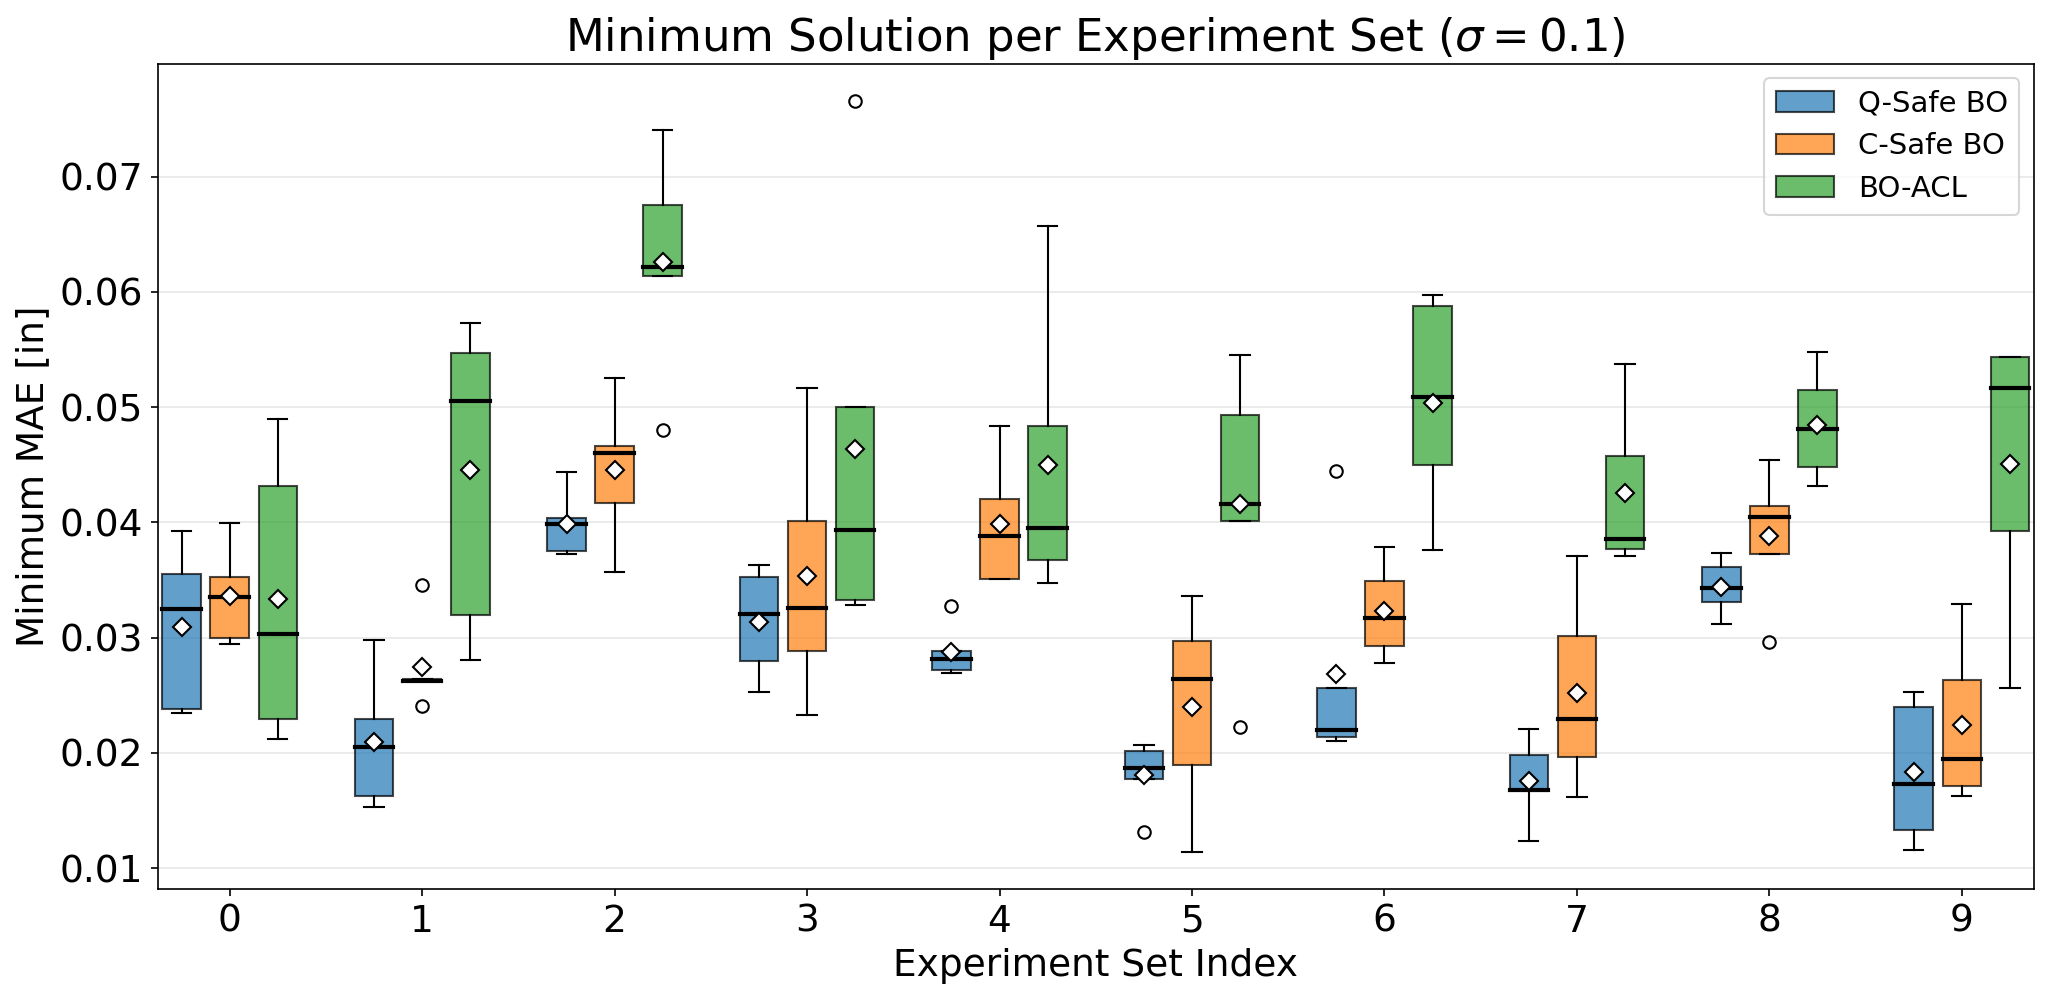

In [ ]:
# ─── Box plot: min solution per experiment set (σ=0.1, 10 exp sets × 5 seeds) ─
num_exp_sets = 10
num_seeds    = 5

box_q01 = []
box_c01 = []
box_acl01 = []

for exp_idx in range(num_exp_sets):
    exp_tag = f'exp_set_{exp_idx}'
    q01_vals, c01_vals, acl01_vals = [], [], []
    for itr in range(num_seeds):
        noise_tag = str(0.1**2)
        fname = q_file_base + noise_tag + '/' + exp_tag + '/' + noise_tag + 'quan_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        q01_vals.append(tr.detach().cpu().numpy().min().item())
        noise_tag_c = str(0.1**2)
        fname = c_file_base + noise_tag_c + '/' + exp_tag + '/' + noise_tag_c + 'classic_safeset_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        c01_vals.append(tr.detach().cpu().numpy().min().item())
        noise_tag_acl = str(0.1**2)
        fname = c_acl_file_base + noise_tag_acl + '/' + exp_tag + '/' + noise_tag_acl + 'training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        acl01_vals.append(tr.detach().cpu().numpy().min().item())
    box_q01.append(q01_vals)
    box_c01.append(c01_vals)
    box_acl01.append(acl01_vals)
    print(f'{exp_tag}: Q min={min(q01_vals):.5f}, C min={min(c01_vals):.5f}, ACL min={min(acl01_vals):.5f}')

plt.rc('font', size=18)
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600

fig, ax = plt.subplots(figsize=(14, 7))

positions_q = np.arange(num_exp_sets) * 4
positions_c = positions_q + 1
positions_acl = positions_q + 2

bp_q = ax.boxplot(box_q01, positions=positions_q, widths=0.8, patch_artist=True,
                  showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                  medianprops=dict(color='black', linewidth=2))
bp_c = ax.boxplot(box_c01, positions=positions_c, widths=0.8, patch_artist=True,
                  showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                  medianprops=dict(color='black', linewidth=2))
bp_acl = ax.boxplot(box_acl01, positions=positions_acl, widths=0.8, patch_artist=True,
                    showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                    medianprops=dict(color='black', linewidth=2))

for patch in bp_q['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp_c['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp_acl['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

ax.set_xticks(positions_q + 1)
ax.set_xticklabels([str(i) for i in range(num_exp_sets)])
ax.set_xlabel('Experiment Set Index')
ax.set_ylabel('Minimum MAE [in]')
ax.set_title('Minimum Solution per Experiment Set ($\\sigma=0.1$)')
ax.legend([bp_q['boxes'][0], bp_c['boxes'][0], bp_acl['boxes'][0]], ['Q-Safe BO', 'C-Safe BO', 'BO-ACL'], loc='upper right', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

exp_set_0: Q min=0.02558, C min=0.03236, ACL min=0.02075
exp_set_1: Q min=0.02455, C min=0.02366, ACL min=0.03200
exp_set_2: Q min=0.03983, C min=0.05543, ACL min=0.04805
exp_set_3: Q min=0.03133, C min=0.03865, ACL min=0.03937
exp_set_4: Q min=0.03344, C min=0.03558, ACL min=0.03670
exp_set_5: Q min=0.01896, C min=0.01896, ACL min=0.02225
exp_set_6: Q min=0.02348, C min=0.02770, ACL min=0.03758
exp_set_7: Q min=0.02915, C min=0.02767, ACL min=0.03711
exp_set_8: Q min=0.03852, C min=0.04225, ACL min=0.04319
exp_set_9: Q min=0.02515, C min=0.02133, ACL min=0.04415


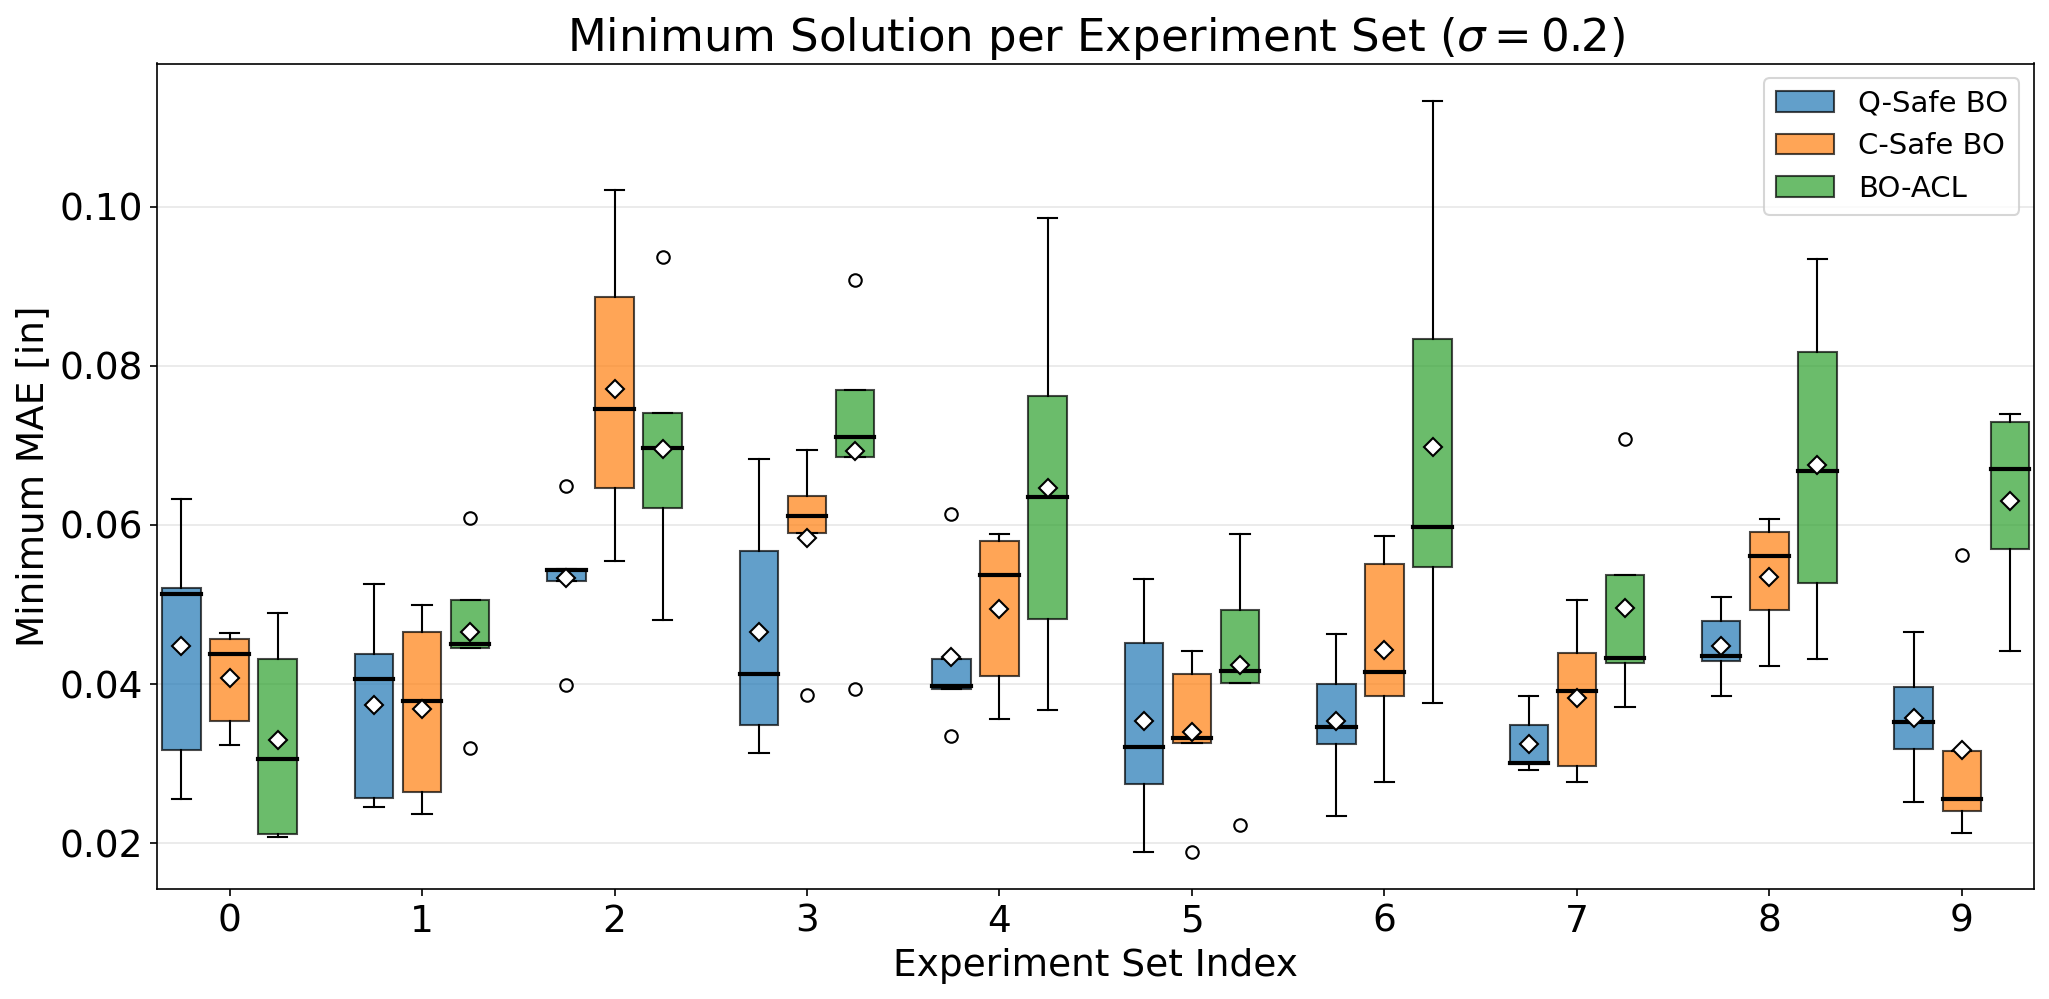

In [ ]:
# ─── Box plot: min solution per experiment set (σ=0.2, 10 exp sets × 5 seeds) ─
num_exp_sets = 10
num_seeds    = 5

box_q04 = []
box_c04 = []
box_acl04 = []

for exp_idx in range(num_exp_sets):
    exp_tag = f'exp_set_{exp_idx}'
    q04_vals, c04_vals, acl04_vals = [], [], []
    for itr in range(num_seeds):
        noise_tag = str(0.2**2)
        fname = q_file_base + noise_tag + '/' + exp_tag + '/' + noise_tag + 'quan_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        q04_vals.append(tr.detach().cpu().numpy().min().item())
        noise_tag_c = str(0.2**2)
        fname = c_file_base + noise_tag_c + '/' + exp_tag + '/' + noise_tag_c + 'classic_safeset_training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        c04_vals.append(tr.detach().cpu().numpy().min().item())
        noise_tag_acl = str(0.2**2)
        fname = c_acl_file_base + noise_tag_acl + '/' + exp_tag + '/' + noise_tag_acl + 'training_data_' + str(itr) + '_.pth'
        _, tr, _, _, _, _ = load_data_wo_constraint(fname, device)
        acl04_vals.append(tr.detach().cpu().numpy().min().item())
    box_q04.append(q04_vals)
    box_c04.append(c04_vals)
    box_acl04.append(acl04_vals)
    print(f'{exp_tag}: Q min={min(q04_vals):.5f}, C min={min(c04_vals):.5f}, ACL min={min(acl04_vals):.5f}')

plt.rc('font', size=18)
plt.rcParams['figure.dpi'] = 600
plt.rcParams['savefig.dpi'] = 600

fig, ax = plt.subplots(figsize=(14, 7))

positions_q = np.arange(num_exp_sets) * 4
positions_c = positions_q + 1
positions_acl = positions_q + 2

bp_q = ax.boxplot(box_q04, positions=positions_q, widths=0.8, patch_artist=True,
                  showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                  medianprops=dict(color='black', linewidth=2))
bp_c = ax.boxplot(box_c04, positions=positions_c, widths=0.8, patch_artist=True,
                  showmeans=True,
                  meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                  medianprops=dict(color='black', linewidth=2))
bp_acl = ax.boxplot(box_acl04, positions=positions_acl, widths=0.8, patch_artist=True,
                    showmeans=True,
                    meanprops=dict(marker='D', markerfacecolor='white', markeredgecolor='black', markersize=6),
                    medianprops=dict(color='black', linewidth=2))

for patch in bp_q['boxes']:
    patch.set_facecolor('#1f77b4')
    patch.set_alpha(0.7)
for patch in bp_c['boxes']:
    patch.set_facecolor('#ff7f0e')
    patch.set_alpha(0.7)
for patch in bp_acl['boxes']:
    patch.set_facecolor('#2ca02c')
    patch.set_alpha(0.7)

ax.set_xticks(positions_q + 1)
ax.set_xticklabels([str(i) for i in range(num_exp_sets)])
ax.set_xlabel('Experiment Set Index')
ax.set_ylabel('Minimum MAE [in]')
ax.set_title('Minimum Solution per Experiment Set ($\\sigma=0.2$)')
ax.legend([bp_q['boxes'][0], bp_c['boxes'][0], bp_acl['boxes'][0]], ['Q-Safe BO', 'C-Safe BO', 'BO-ACL'], loc='upper right', fontsize=14)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Violation Rate Report for `exp_set_0`

This report is aligned with the cumulative regret and running-minimum plots, which use `exp_tag = 'exp_set_0'` and five seeds. Violation rate is computed as `unsafe / total`, where a point is safe when `(1 - FI) > 0` under `surrogate_tsaiwu.joblib`.

#### Aggregate over five seeds

| Method | Noise variance | Safe | Unsafe | Total | Violation rate | Seed std |
|---|---:|---:|---:|---:|---:|---:|
| Q-Safe BO | 0.01 | 1781 | 0 | 1781 | 0.000000 | 0.000000 |
| C-Safe BO | 0.01 | 1169 | 0 | 1169 | 0.000000 | 0.000000 |
| BO-ACL | 0.01 | 1315 | 1670 | 2985 | 0.559464 | 0.007416 |
| Q-Safe BO | 0.04 | 778 | 0 | 778 | 0.000000 | 0.000000 |
| C-Safe BO | 0.04 | 492 | 0 | 492 | 0.000000 | 0.000000 |
| BO-ACL | 0.04 | 529 | 976 | 1505 | 0.648505 | 0.012850 |

#### Per-seed violation rates

| Method | Noise variance | Seed | Safe | Unsafe | Total | Violation rate |
|---|---:|---:|---:|---:|---:|---:|
| Q-Safe BO | 0.01 | 0 | 343 | 0 | 343 | 0.000000 |
| Q-Safe BO | 0.01 | 1 | 371 | 0 | 371 | 0.000000 |
| Q-Safe BO | 0.01 | 2 | 367 | 0 | 367 | 0.000000 |
| Q-Safe BO | 0.01 | 3 | 327 | 0 | 327 | 0.000000 |
| Q-Safe BO | 0.01 | 4 | 373 | 0 | 373 | 0.000000 |
| C-Safe BO | 0.01 | 0 | 248 | 0 | 248 | 0.000000 |
| C-Safe BO | 0.01 | 1 | 209 | 0 | 209 | 0.000000 |
| C-Safe BO | 0.01 | 2 | 224 | 0 | 224 | 0.000000 |
| C-Safe BO | 0.01 | 3 | 258 | 0 | 258 | 0.000000 |
| C-Safe BO | 0.01 | 4 | 230 | 0 | 230 | 0.000000 |
| BO-ACL | 0.01 | 0 | 265 | 332 | 597 | 0.556114 |
| BO-ACL | 0.01 | 1 | 262 | 335 | 597 | 0.561139 |
| BO-ACL | 0.01 | 2 | 255 | 342 | 597 | 0.572864 |
| BO-ACL | 0.01 | 3 | 265 | 332 | 597 | 0.556114 |
| BO-ACL | 0.01 | 4 | 268 | 329 | 597 | 0.551089 |
| Q-Safe BO | 0.04 | 0 | 158 | 0 | 158 | 0.000000 |
| Q-Safe BO | 0.04 | 1 | 149 | 0 | 149 | 0.000000 |
| Q-Safe BO | 0.04 | 2 | 157 | 0 | 157 | 0.000000 |
| Q-Safe BO | 0.04 | 3 | 157 | 0 | 157 | 0.000000 |
| Q-Safe BO | 0.04 | 4 | 157 | 0 | 157 | 0.000000 |
| C-Safe BO | 0.04 | 0 | 99 | 0 | 99 | 0.000000 |
| C-Safe BO | 0.04 | 1 | 99 | 0 | 99 | 0.000000 |
| C-Safe BO | 0.04 | 2 | 94 | 0 | 94 | 0.000000 |
| C-Safe BO | 0.04 | 3 | 100 | 0 | 100 | 0.000000 |
| C-Safe BO | 0.04 | 4 | 100 | 0 | 100 | 0.000000 |
| BO-ACL | 0.04 | 0 | 109 | 192 | 301 | 0.637874 |
| BO-ACL | 0.04 | 1 | 111 | 190 | 301 | 0.631229 |
| BO-ACL | 0.04 | 2 | 101 | 200 | 301 | 0.664452 |
| BO-ACL | 0.04 | 3 | 102 | 199 | 301 | 0.661130 |
| BO-ACL | 0.04 | 4 | 106 | 195 | 301 | 0.647841 |


### Violation Rate — `exp_set_0` (all methods)

Queried point is **safe** when `(1 - FI) > 0` under `surrogate_tsaiwu.joblib`; **violation rate = unsafe / total** over the evaluated action rows of `exp_set_0` (one row per BO stage — not the oracle `queries` cost). `mean ± std` are over the 5 seeds of `exp_set_0`; `Unsafe/Total` is pooled over those seeds. Covers Q-Safe BO, C-Safe BO, BO-ACL, C-Unconstrained, and Q-Unconstrained. Requires cell 2 to have run first (uses `is_feasible`, `load_data_wo_constraint`, the `*_file_base` variables, and `device`).

In [ ]:
# ─── Violation rate for exp_set_0 across ALL methods ─────────────────────────
# safe: (1 - FI) > 0  |  violation_rate = unsafe / evaluated action rows.
# mean +/- std over the 5 seeds of exp_set_0;  Unsafe/Total pooled over those seeds.
import os

exp_tag_v = 'exp_set_0'
num_seeds_v = 5

# (method label, dir/file base, {full-noise-tag: dir&file tag}, file suffix)
all_methods_v = [
    ('Q-Safe BO', q_file_base,
     {str(0.1**2): str(0.1**2), str(0.2**2): str(0.2**2)}, 'quan_training_data_'),
    ('C-Safe BO', c_file_base,
     {str(0.1**2): str(0.1**2), str(0.2**2): str(0.2**2)}, 'classic_safeset_training_data_'),
    ('BO-ACL', c_acl_file_base,
     {str(0.1**2): str(0.1**2), str(0.2**2): str(0.2**2)}, 'training_data_'),
    ('C-Unconstrained', unc_file_base,
     {str(0.1**2): str(0.1**2), str(0.2**2): str(0.2**2)}, 'classic_unconstrained_training_data_'),
    ('Q-Unconstrained', unc_q_file_base,
     {str(0.1**2): '0.01', str(0.2**2): '0.04'}, 'quan_unconstrained_training_data_'),
]

exp0_noise_levels = [
    ('$\sigma=0.1$ (var=0.01)', str(0.1**2)),
    ('$\sigma=0.2$ (var=0.04)', str(0.2**2)),
]

print('=== Violation rate for exp_set_0 (all methods) ===')
print('safe: (1 - FI) > 0  |  violation_rate = unsafe / evaluated action rows')
print('mean +/- std over 5 seeds;  Unsafe/Total pooled over 5 seeds\n')

exp0_violation_summary = {}
for method_label, file_base, tag_map, file_suffix in all_methods_v:
    print(f'### {method_label}')
    for noise_label, noise_tag in exp0_noise_levels:
        dir_tag = tag_map[noise_tag]
        seed_vr, seed_rows, seed_unsafe, n_seeds, missing = [], 0, 0, 0, 0
        for itr in range(num_seeds_v):
            fname = (file_base + dir_tag + '/' + exp_tag_v + '/'
                     + dir_tag + file_suffix + str(itr) + '_.pth')
            if not os.path.isfile(fname):
                missing += 1
                continue
            actions, _, _, _, _, _ = load_data_wo_constraint(fname, device)
            actions_np = actions.detach().cpu().numpy()
            n_total = len(actions_np)
            n_unsafe = sum(1 for a in actions_np if not is_feasible(a))
            seed_vr.append(n_unsafe / n_total if n_total else np.nan)
            seed_rows += n_total
            seed_unsafe += n_unsafe
            n_seeds += 1
        mean_vr = float(np.mean(seed_vr)) if seed_vr else np.nan
        std_vr  = float(np.std(seed_vr)) if seed_vr else np.nan
        pooled  = seed_unsafe / seed_rows if seed_rows else np.nan
        exp0_violation_summary[(method_label, noise_tag)] = {
            'mean': mean_vr, 'std': std_vr, 'unsafe': seed_unsafe, 'rows': seed_rows,
            'n_seeds': n_seeds, 'missing': missing,
        }
        print(f'  {noise_label}: mean violation_rate = {mean_vr:.4f} (std {std_vr:.4f}), '
              f'unsafe/total = {seed_unsafe}/{seed_rows} = {pooled:.4f} '
              f'(n_seeds={n_seeds}, missing={missing})')
    print()

# ─── Markdown-style summary table ───────────────────────────────────────────
print('| Method | Noise | Violation rate | Std | Unsafe/Total | n (seeds) |')
print('|---|---:|---:|---:|---:|---:|')
for method_label, file_base, tag_map, file_suffix in all_methods_v:
    for noise_label, noise_tag in exp0_noise_levels:
        s = exp0_violation_summary[(method_label, noise_tag)]
        sig = '0.01' if noise_tag == str(0.1**2) else '0.04'
        print(f"| {method_label} | {sig} | {s['mean']:.4f} | {s['std']:.4f} | {s['unsafe']}/{s['rows']} | {s['n_seeds']} |")


### Best-Min Objective — `Experiments_unconstraint_continuous` (ten-trial statistics)

Best (minimum) ground-truth objective (`true_response`, MAE) found per run. **Two-level aggregation:** for each `exp_set_0..9`, average the per-run minimum over its 5 seeds (→ 10 per-exp_set values), then report **mean ± std across those 10 values**. Requires cell 2 to have run first (uses `load_data_wo_constraint`, `unc_file_base`, `device`).

In [ ]:
# ─── Best-min objective: ten-trial statistics (UNCONSTRAINED) ────────────────
# Level 1: average per-run min(true_response) over 5 seeds within each exp_set.
# Level 2: mean +/- std across the 10 exp_set values.
# Covers both Classic and Quantum unconstrained baselines.
import os

num_exp_sets_unc = 10
num_seeds_unc    = 5

# (method label, dir/file base, {full-noise-tag: dir&file tag}, file suffix)
unc_methods = [
    ('BO-Unconstrained (Classic)', unc_file_base,
     {str(0.1**2): str(0.1**2), str(0.2**2): str(0.2**2)},
     'classic_unconstrained_training_data_'),
    ('BO-Unconstrained (Quantum)', unc_q_file_base,
     {str(0.1**2): '0.01', str(0.2**2): '0.04'},
     'quan_unconstrained_training_data_'),
]

unc_noise_levels = [
    ('$\\sigma=0.1$ (var=0.01)', str(0.1**2)),
    ('$\\sigma=0.2$ (var=0.04)', str(0.2**2)),
]

print('=== BO-Unconstrained best-min objective (ten-trial statistics) ===')
print('Level 1: mean of per-run min(true_response) over 5 seeds per exp_set')
print('Level 2: mean +/- std over the 10 exp_set values\n')

unc_min_summary = {}
for method_label, file_base, tag_map, file_suffix in unc_methods:
    print(f'### {method_label}')
    for noise_label, noise_tag in unc_noise_levels:
        dir_tag = tag_map[noise_tag]
        per_expset_mean = []
        missing = 0
        print(noise_label)
        for exp_idx in range(num_exp_sets_unc):
            exp_tag = f'exp_set_{exp_idx}'
            seed_min = []
            for itr in range(num_seeds_unc):
                fname = (file_base + dir_tag + '/' + exp_tag + '/'
                         + dir_tag + file_suffix + str(itr) + '_.pth')
                if not os.path.isfile(fname):
                    missing += 1
                    continue
                _, unc_true_response, _, _, _, _ = load_data_wo_constraint(fname, device)
                seed_min.append(float(unc_true_response.detach().cpu().numpy().min()))
            if seed_min:
                m = float(np.mean(seed_min))
                per_expset_mean.append(m)
                print(f'  {exp_tag}: seed-avg min = {m:.5f}  (n_seeds={len(seed_min)})')
        per_expset_mean = np.array(per_expset_mean)
        grand_mean = float(np.mean(per_expset_mean)) if len(per_expset_mean) else np.nan
        grand_std  = float(np.std(per_expset_mean)) if len(per_expset_mean) else np.nan
        grand_std1 = float(np.std(per_expset_mean, ddof=1)) if len(per_expset_mean) > 1 else np.nan
        unc_min_summary[(method_label, noise_tag)] = {
            'per_expset_mean': per_expset_mean,
            'mean': grand_mean, 'std': grand_std, 'std_ddof1': grand_std1,
            'n_exp_sets': len(per_expset_mean), 'missing': missing,
        }
        print(f'  --> across {len(per_expset_mean)} exp_sets: '
              f'mean = {grand_mean:.5f} , std = {grand_std:.5f} , std(ddof=1) = {grand_std1:.5f}')
        print(f'      (missing files: {missing})\n')

print('| Method | Noise | Best-min | Std | Std(ddof=1) | n (exp_sets) |')
print('|---|---:|---:|---:|---:|---:|')
for method_label, file_base, tag_map, file_suffix in unc_methods:
    for noise_label, noise_tag in unc_noise_levels:
        s = unc_min_summary[(method_label, noise_tag)]
        sig = '0.01' if noise_tag == str(0.1**2) else '0.04'
        n_flag = f"{s['n_exp_sets']}" + (' (partial)' if s['n_exp_sets'] < num_exp_sets_unc else '')
        print(f"| {method_label} | {sig} | {s['mean']:.5f} | {s['std']:.5f} | {s['std_ddof1']:.5f} | {n_flag} |")
